<a href="https://colab.research.google.com/github/dominikkrisnah/Earth-Science_Project/blob/main/Ocean_Atmosphere_Interactions/Ocean_Anomalies/Identifying_El_Ni%C3%B1o_Phenomenon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## By: **Dominikus Krisna Herlambang | ©2023**

# Big Data Analysis to Identify Climate Phenomena in a Specific Year - Study: Identifying the El-Niño Phenomenon

In [1]:
# Install the Earth Engine API latest update
!pip install geemap earthengine-api cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 65.1 MB/s eta 0:00:00


In [2]:
!earthengine authenticate

E0000 00:00:1775018847.459763    2967 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775018847.466188    2967 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775018847.482391    2967 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775018847.482433    2967 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775018847.482437    2967 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775018847.482442    2967 computation_placer.cc:177] computation placer already registered. Please check linka

In [3]:
import ee
import geemap
import geemap.colormaps as cm
from geemap import cartoee
import cartopy.crs as ccrs

# loads packages for local graphing and data structure creation
import altair as alt
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
#%pylab inline

In [4]:
#geemap.ee_initialize()
ee.Initialize()

In [5]:
Map = geemap.Map()
Map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(childr…

In [6]:
Map.setCenter(200, -3, 2);

In [7]:
# Function to Load NOAA CDR OISST v02r01 data
def parameter(image):
  par = image.select(['anom']) \
  .multiply(0.01)

  return image.select().addBands([par])

In [8]:
# load downscaled NOAA CDR OISST v02r01 data and
# get "anom" bands
# filter to specific models and scenarios
climate_temp = (
    ee.ImageCollection("NOAA/CDR/OISST/V2_1")
    .map(parameter)
)

In [9]:
# print the first 10 images of sst-anom in the collection
climate_temp.limit(10)

In [10]:
# menyaring koleksi tahun 2024 dan menghitung rata-ratanya
present_temp = (
    climate_temp
    .filterDate('2024-01-01', '2024-12-07')
    .mean()
)

In [11]:
# filter the 2024 collection and calculate the average
temp_vis = {
    'min': -2.5,
    'max': 2.5,
    'palette': cm.get_palette('RdBu_r')
}

In [37]:
# add sst anomaly to Map layer
Map.add_layer(
    present_temp,
    temp_vis,
    'sst'
)

## Menghitung index NINO 3.4

In [13]:
# Focus area Nino3.4 (170W - 120W, 5S - 5N)
nino_region = ee.Geometry.Polygon(
    [[[190, -5],
      [240, -5],
      [240, 5],
      [190, 5],
      [190, -5]]], None, False)  # exp: Nino3.4 Area

In [39]:
# Clip data "present_temp" using Nino3.4 area
clipped_nino = present_temp.clip(nino_region)

# add the clipped anomaly to the Map layer
Map.addLayer(
    clipped_nino,
    temp_vis,
    'nino3.4_clipped'
)

# Adjust the viewing angle to be right in the middle
Map.centerObject(nino_region, 2)

In [15]:
# Function to extract SST values ​​from ImageCollection
# into a timeseries in one dataframe
def extract_sst(image):
    """
    Ekstrak rata-rata SST dan mengembalikan fitur
    dengan tanggal dan properti SST.
    """
    mean_sst = image.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=nino_region,
        scale=5000,  # Adjust the scale as needed
        maxPixels=1e14
    ).get('anom')
    # Create a feature with date and SST properties
    return ee.Feature(None, {'date': image.date().format('YYYY-MM-dd'), 'sst': mean_sst})

# Filter by date and map function
anom_timeseries = climate_temp.filterDate('2000-01-01', '2024-12-05').map(extract_sst)

# Convert to list of dictionaries
anom_data = anom_timeseries.toList(anom_timeseries.size()).map(lambda feature: ee.Feature(feature).toDictionary()).getInfo()

# Extract date and SST value
dates = [item.get('date') for item in anom_data]
anom_values = [item.get('sst') for item in anom_data]

In [16]:
# Create DataFrame
sst_anom_daily = pd.DataFrame({'Date': dates, 'SST': anom_values})
sst_anom_daily.head(3)

,Date,SST
0,2000-01-01,-1.878645
1,2000-01-02,-1.953314
2,2000-01-03,-1.966685


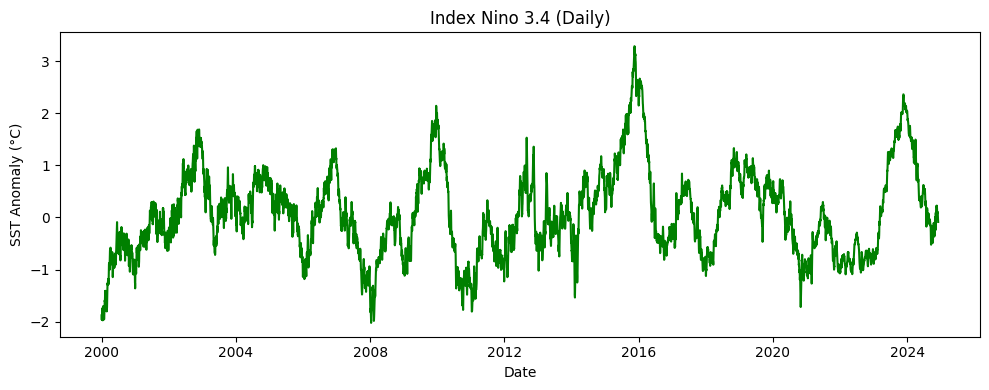

In [17]:
# Convert the 'Date' column to a datetime object
sst_anom_daily['Date'] = pd.to_datetime(sst_anom_daily['Date'])

# Plot of daily anomalies
plt.figure(figsize=(10, 4))
plt.plot(sst_anom_daily['Date'], sst_anom_daily['SST'],
         color='green')
plt.xlabel('Date')
plt.ylabel('SST Anomaly (°C)')
plt.title('Index Nino 3.4 (Daily)')
plt.tight_layout()
plt.show()

In [18]:
# Group the data by month and
# calculate the average SST anomaly for each month
sst_anom_monthly = sst_anom_daily.groupby(sst_anom_daily['Date'].dt.to_period('M'))['SST'].mean().reset_index()

# Change the name of the column 'Date' to 'Month'
sst_anom_monthly.rename(columns={'Date': 'Month'}, inplace=True)

# Convert the 'Month' column back to a datetime object for plotting
sst_anom_monthly['Month'] = sst_anom_monthly['Month'].dt.to_timestamp()
sst_anom_monthly.head(3)

,Month,SST
0,2000-01-01,-1.854407
1,2000-02-01,-1.623141
2,2000-03-01,-1.133243


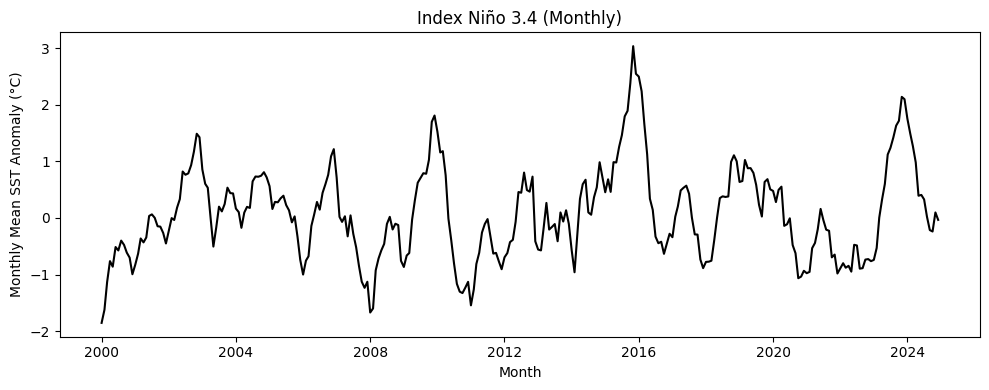

In [19]:
# Monthly anomaly plot
plt.figure(figsize=(10, 4))
plt.plot(sst_anom_monthly['Month'], sst_anom_monthly['SST'],
         linewidth=1.5 ,color='black', label='Monthly SST Anomaly')
plt.xlabel('Month')
plt.ylabel('Monthly Mean SST Anomaly (°C)')
plt.title('Index Niño 3.4 (Monthly)')
plt.tight_layout()
plt.show()

In [20]:
# Calculate the standard deviation of the values
# in the 'SST' column in sst_anom_monthly
std_dev = sst_anom_monthly['SST'].std()
print(f"Standard deviation dari sst_anom_monthly: {std_dev}")

Standard deviation dari sst_anom_monthly: 0.8158804472281443


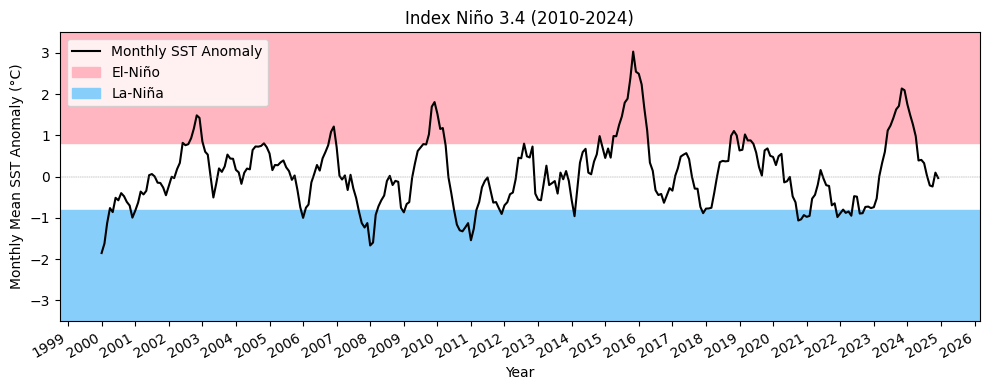

In [21]:
# Visualization of the Nino-3.4 Index for 2010-2024
plt.figure(figsize=(10, 4))
# Monthly anomaly visualization
plt.plot(sst_anom_monthly['Month'], sst_anom_monthly['SST'],
         linewidth=1.5 ,color='black', label='Monthly SST Anomaly')
plt.xlabel('Year')
plt.ylabel('Monthly Mean SST Anomaly (°C)')
plt.title('Index Niño 3.4 (2010-2024)')
# Set the y-axis to have the same range of values
plt.ylim(-3.5,3.5)
# Displays the center line at the value "y = 0"
plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.3)
# Set the x-axis to show all years
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
# Gives background color to the threshold
plt.axhspan(0.815, 3.5, color='lightpink', label='El-Niño')
plt.axhspan(-3.5, -0.815, color='lightskyblue', label='La-Niña')
# Rotate the date label for easier reading
plt.gcf().autofmt_xdate()
plt.legend(loc='best') # Bringing out the legend
plt.tight_layout()
plt.show()

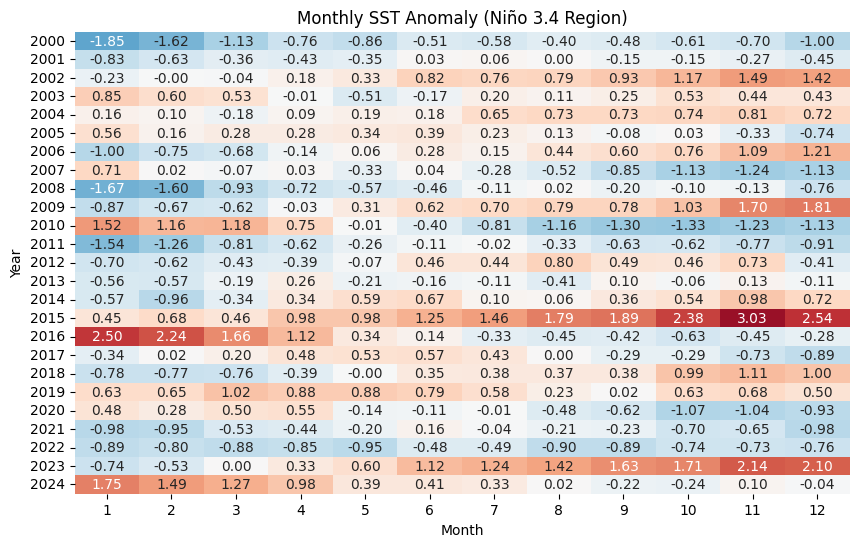

In [25]:
# A specific look at the El-Niño phenomenon
# Displaying the Niño Index in the form of a heatmap diagram
plt.figure(figsize=(10, 6))
sns.heatmap(sst_anom_monthly.pivot_table(index=sst_anom_monthly['Month'].dt.year,
                                         columns=sst_anom_monthly['Month'].dt.month, values='SST'),
            cmap='RdBu_r', annot=True, fmt=".2f", vmin=-3.5, vmax=3.5,
            cbar=False)
plt.title('Monthly SST Anomaly (Niño 3.4 Region)')
plt.xlabel('Month')
plt.ylabel('Year')
plt.show()

In [26]:
# Monthly data filter for 2023 and 2024
sst_anom_monthly_2023_2024 = sst_anom_monthly[
    (sst_anom_monthly['Month'].dt.year == 2023) | (sst_anom_monthly['Month'].dt.year == 2024)
]
sst_anom_monthly_2023_2024.head()

,Month,SST
276,2023-01-01,-0.742213
277,2023-02-01,-0.531014
278,2023-03-01,0.004901
279,2023-04-01,0.328946
280,2023-05-01,0.600094


In [27]:
# Save DataFrame sst_anom_monthly to Excel file
sst_anom_monthly.to_excel('sst_anom_monthly.xlsx', index=False)

## Processing and converting actual spatial data from daily to monthly

In [28]:
# Focus area Pacific Ocean
roi = ee.Geometry.Polygon(
        [[[90, -20],
          [300, -20],
          [300, 30],
          [90, 30],
          [90, -20]]], None, False)  # Exp: Pacific Area

In [40]:
# Clip data "present_temp" using the Pacific Ocean area
clipped_temp = present_temp.clip(roi)

# add the clipped anomaly to the Map layer
Map.addLayer(
    clipped_temp,
    temp_vis,
    'sst_clipped'
)

# Adjust the viewing angle to be right in the middle
Map.centerObject(roi, 2)

In [31]:
# Function to convert cropped images into monthly spatial data
def monthly_spatial_data(image, start_date, end_date, roi):
    # Create a date sequence for a monthly interval
    date_range = pd.date_range(start=start_date, end=end_date, freq='MS')

    monthly_data = []

    for month_start in date_range:
        month_end = month_start + pd.DateOffset(months=1)
        month_start_str = month_start.strftime('%Y-%m-%d')
        month_end_str = month_end.strftime('%Y-%m-%d')

        # Filter the image collection for the month to be visualized
        monthly_image = (
            climate_temp
            .filterDate(month_start_str, month_end_str)
            .mean()
            .clip(roi)
        )
        # Add relevant data
        # Data extraction
        monthly_data.append({
            'date': month_start_str,
            'image': monthly_image # Store the entire image object
        })

    return monthly_data

# Set the start to end of the
# months to be visualized
start_date = '2023-01-01'
end_date = '2024-12-31'

monthly_sst_data = monthly_spatial_data(clipped_temp, start_date, end_date, roi)
monthly_sst_data

[{'date': '2023-01-01', 'image': <ee.image.Image at 0x786a28afbec0>},
 {'date': '2023-02-01', 'image': <ee.image.Image at 0x786a23cb6c60>},
 {'date': '2023-03-01', 'image': <ee.image.Image at 0x786a28aabe60>},
 {'date': '2023-04-01', 'image': <ee.image.Image at 0x786a23eefef0>},
 {'date': '2023-05-01', 'image': <ee.image.Image at 0x786a23eec440>},
 {'date': '2023-06-01', 'image': <ee.image.Image at 0x786a289ebd10>},
 {'date': '2023-07-01', 'image': <ee.image.Image at 0x786a2cb2a930>},
 {'date': '2023-08-01', 'image': <ee.image.Image at 0x786a2cb29d30>},
 {'date': '2023-09-01', 'image': <ee.image.Image at 0x786a2cb29ee0>},
 {'date': '2023-10-01', 'image': <ee.image.Image at 0x786a28b29f70>},
 {'date': '2023-11-01', 'image': <ee.image.Image at 0x786a28b29f10>},
 {'date': '2023-12-01', 'image': <ee.image.Image at 0x786a23a5b2c0>},
 {'date': '2024-01-01', 'image': <ee.image.Image at 0x786a28cc3920>},
 {'date': '2024-02-01', 'image': <ee.image.Image at 0x786a28ba0440>},
 {'date': '2024-03-0

In [41]:
# Filter monthly sst data to be visualized
Anomaly_ElNino = [item for item in monthly_sst_data if item['date'].startswith('2023-10')]
ElNino = Anomaly_ElNino[0]['image']

# Visualize El-Nino phenomenon data on a map
Map.addLayer(
    ElNino,
    temp_vis,
    'October 2023 SST'
    )
Map.add_colorbar(
    temp_vis,
    label="SST Anomaly (°C)",
    layer_name="October 2023 SST"
    )
Map

Map(bottom=787.0, center=[8.754794702435618, -164.88281250000003], controls=(WidgetControl(options=['position'…

## Visualize the visualization results in the Map cell by using the Cartoee package so that the results can be saved.

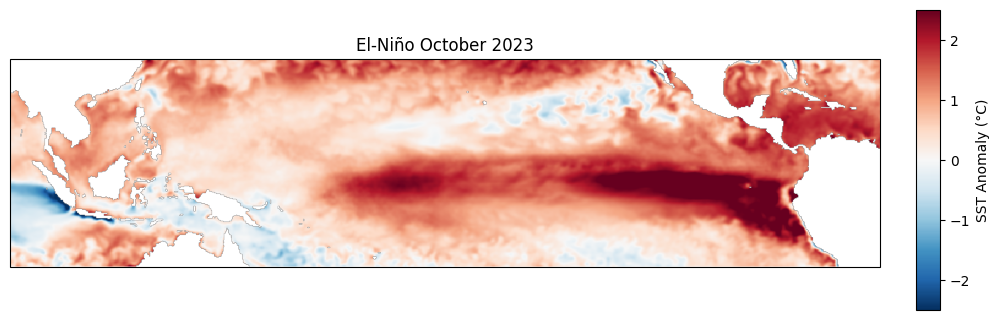

In [34]:
fig = plt.figure(figsize=(12, 6))

# Define orthographic projection
projection = ccrs.PlateCarree(central_longitude=180, globe=None)

# Create an axis with the specified projection
ax = plt.axes(projection=projection)

# Set the map area
ax.set_extent([90, 300, -20, 30], crs=ccrs.PlateCarree())
# Use cartoee to display El-Niño data
# Use 'vis_params' with 'palette'
cartoee.add_layer(ax, ElNino, vis_params=temp_vis)
plt.title('El-Niño October 2023')
# Add colorbar
cartoee.add_colorbar(
    ax, vis_params=temp_vis, loc='right',
    orientation='vertical',
    label='SST Anomaly (°C)'
)
plt.show()